In [1]:
import icechunk
import matplotlib.pyplot as plt
import zarr
import numpy as np

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
calculate_reasonable_bounds_doy
)
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
    #"s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/plausible_value_check/"
branch = "v0.10.0" #"qa-qc-downscaling-step/vtest01"  # 


var = "tasmax"
scenario = "ssp245"
ens = "008"
spatial_subset=False

In [ ]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm", #"carbonplan-scratch",  
    prefix=#"srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    "output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
print(root.tree())

In [4]:
debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [5]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

In [6]:
raw_scenario=catalog.get("CESM2-WACCM").to_xarray()[scenario][var].sel(ensemble_member=ens)
raw_historical=catalog.get("CESM2-WACCM").to_xarray()["historical"][var]

In [7]:
if spatial_subset:
    obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
    raw_scenario_subset=raw_scenario.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
    raw_historical_subset=raw_historical.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
else:
    obs_fine_subset=obs_fine
    raw_scenario_subset=raw_scenario
    raw_historical_subset=raw_historical

# Calculate bounds

In [8]:
low_bound, high_bound=calculate_reasonable_bounds_doy(raw_scenario_subset=raw_scenario_subset, 
                               raw_historical_subset=raw_historical_subset,
                               obs_fine_subset=obs_fine_subset)

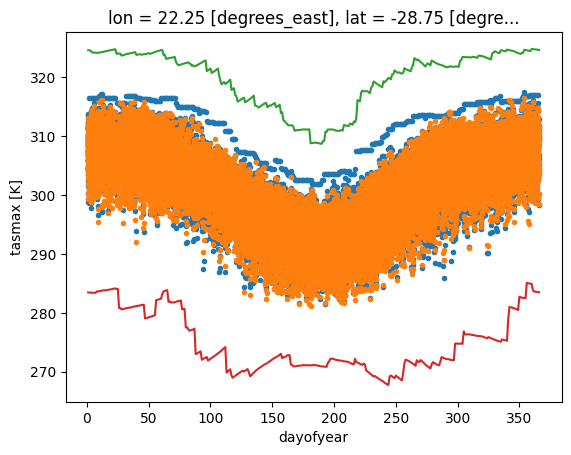

In [9]:
ilat=-28.75
ilon=22.25
plt.plot(debiased_downscaled['time.dayofyear'],debiased_downscaled.sel(lat=ilat,lon=ilon,method='nearest'),'.')
plt.plot(raw_scenario_subset['time.dayofyear'],(raw_scenario_subset.sel(lat=ilat,lon=ilon,method='nearest')),'.')
(high_bound.sel(lat=ilat,lon=ilon,method='nearest')).plot()
(low_bound.sel(lat=ilat,lon=ilon,method='nearest')).plot()

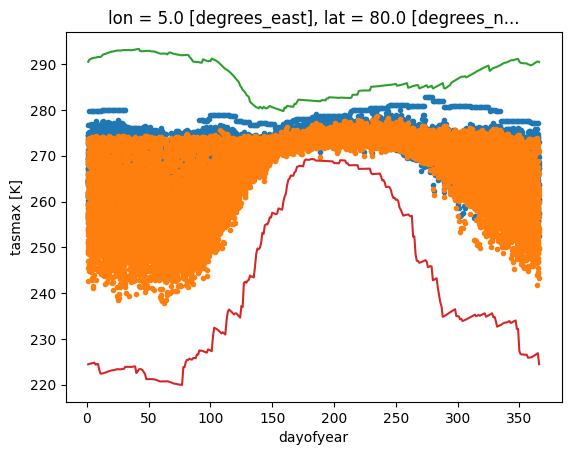

In [10]:
ilat=80
ilon=5
plt.plot(debiased_downscaled['time.dayofyear'],debiased_downscaled.sel(lat=ilat,lon=ilon,method='nearest'),'.')
plt.plot(raw_scenario_subset['time.dayofyear'],(raw_scenario_subset.sel(lat=ilat,lon=ilon,method='nearest')),'.')
(high_bound.sel(lat=ilat,lon=ilon,method='nearest')).plot()
(low_bound.sel(lat=ilat,lon=ilon,method='nearest')).plot()

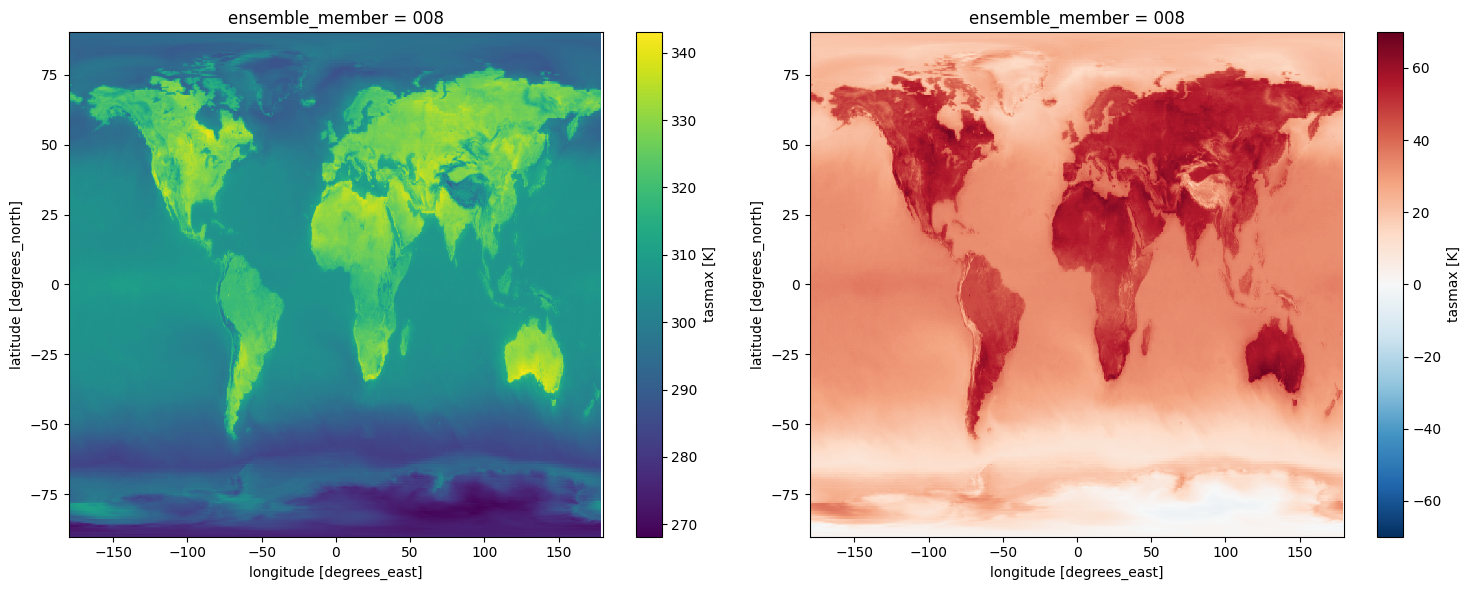

In [11]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
(high_bound.max(dim='dayofyear')).plot()
plt.subplot(1,2,2)
(high_bound.max(dim='dayofyear')-273.15).plot(label='Celsius')
plt.tight_layout()

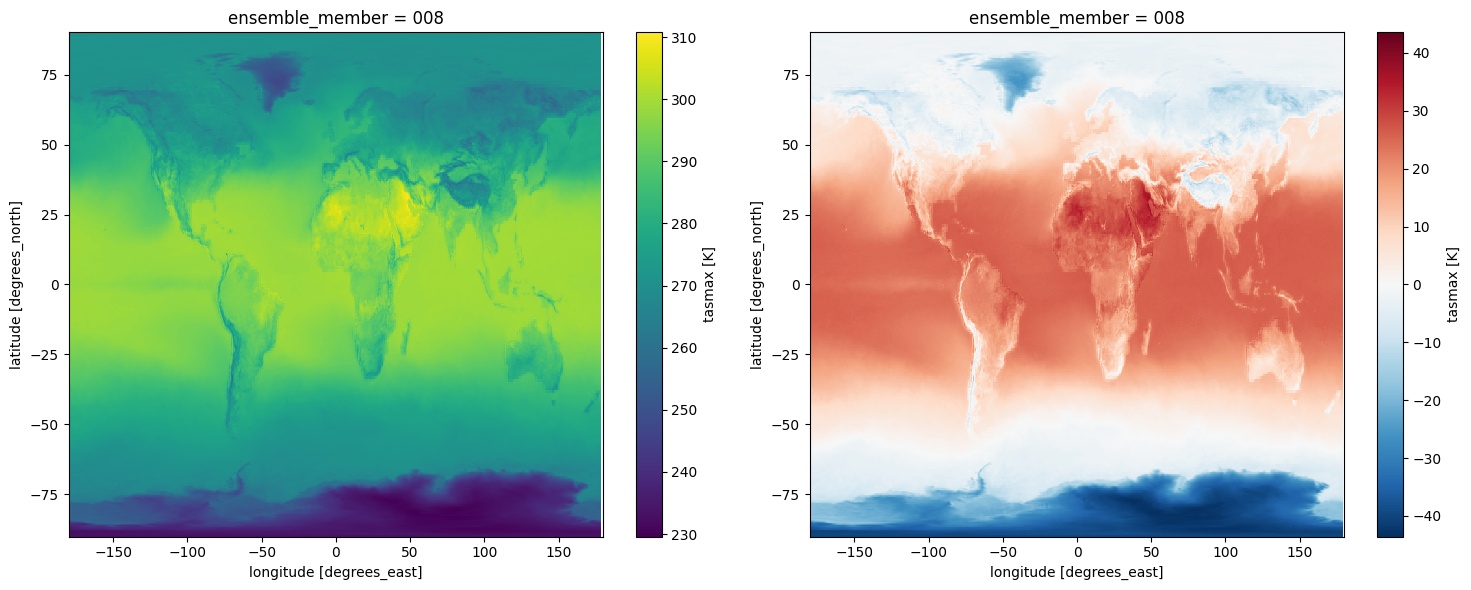

In [12]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
(low_bound.max(dim='dayofyear')).plot()
plt.subplot(1,2,2)
(low_bound.max(dim='dayofyear')-273.15).plot(label='Celsius')
plt.tight_layout()

# Calculate values in bounds

In [ ]:
# Very slow step
doy = debiased_downscaled["time.dayofyear"]
too_high = (debiased_downscaled > high_bound.sel(dayofyear=doy)).mean(dim="time").compute()
too_low = (debiased_downscaled < low_bound.sel(dayofyear=doy)).mean(dim="time").compute()

In [ ]:
too_high_delta = (debiased_downscaled - high_bound.sel(dayofyear=doy))
too_high_delta_max = too_high_delta.where(too_high).max(dim="time").compute()
too_low_delta = (debiased_downscaled - low_bound.sel(dayofyear=doy))
too_low_delta_min = too_high_delta.where(too_low).min(dim="time").compute()

In [ ]:
def print_frac_implausible(too_high, too_low):
    frac_area_too_high = (too_high>0).mean(dim=["lat","lon"]).values
    frac_area_too_low = (too_low>0).mean(dim=["lat","lon"]).values
    print("Fraction of area too high: "+str(frac_area_too_high))
    print("Fraction of area too low: "+str(frac_area_too_low))

In [ ]:
print_frac_implausible(too_high, too_low)

# Plot reasonable checks

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
too_high.plot()
plt.grid()
plt.subplot(1,2,2)
too_high.where(too_high>0).plot()
plt.grid()

In [ ]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
too_low.plot()
plt.grid()
plt.subplot(1,2,2)
too_low.where(too_low>0).plot()
plt.grid()

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

((too_high + too_low) > 0).plot(ax=ax, transform=ccrs.PlateCarree(), label='Outside bounds')

ax.gridlines(draw_labels=True, color='darkgray')
plt.savefig(path_qaqc+'map_out_of_range_'+var+'_'+scenario+'_'+ens+'.png')

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

((too_high_delta_min)).plot(ax=ax, transform=ccrs.PlateCarree(), label='How outside bounds', cmap=plt.cm.viridis, vmin=-5)

ax.gridlines(draw_labels=True, color='darkgray')
plt.savefig(path_qaqc+'map_min_mag_out_of_range_'+var+'_'+scenario+'_'+ens+'.png')

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

((too_high_delta_max)).plot(ax=ax, transform=ccrs.PlateCarree(), label='How outside bounds', cmap=plt.cm.viridis_r, vmax=5)

ax.gridlines(draw_labels=True, color='darkgray')
plt.savefig(path_qaqc+'map_max_mag_out_of_range_'+var+'_'+scenario+'_'+ens+'.png')

In [ ]:
doy = debiased_downscaled["time.dayofyear"]
pt_too_high = (pt_vals > pt_bound_high.sel(dayofyear=doy))
pt_too_low = (pt_vals < pt_bound_low.sel(dayofyear=doy))

In [ ]:
# Look at an example point that is outside the bounds of what is reasonable
ilat=82
ilon=-150

pt_vals = debiased_downscaled.sel(lat=ilat,lon=ilon,method='nearest')
pt_bound_high=(high_bound.sel(lat=ilat,lon=ilon,method='nearest'))
pt_bound_low =(low_bound.sel(lat=ilat,lon=ilon,method='nearest'))
plt.plot(pt_vals['time.dayofyear'],pt_vals,'.k')
plt.plot(pt_vals['time.dayofyear'],pt_vals.where(pt_too_high),'o', fillstyle='none')
plt.plot(pt_vals['time.dayofyear'],pt_vals.where(pt_too_low),'o', fillstyle='none')
#plt.plot(pt_vals['time.dayofyear'],pt_vals.where(pt_vals>high_bound.sel(lat=ilat,lon=ilon,method='nearest')),'o', fillstyle=None)
pt_bound_high.plot()
pt_bound_low.plot()